Curator: Nhu Hue Huynh

Reviewer: 

Title: Extinction and persistence of a stochastic SICA epidemic model with standard incidence rate for HIV transmission

DOI: 10.1186/s13662-021-03392-y

Figure: 1

Outcome: Successful

Notes:  AIDS(d) graph looks slightly different

In [8]:
variable_names = [
    'S', # Susceptible
    'I', # Infected
    'C', # Chronic
    'A', # AIDS symtomps
]
"""Names of the variables in the SDE model. The order of the variables should be the same as the order of the drift and diffusion terms returned by the drift_term and diffusion_term functions."""

parameter_names = [  
    'lam',    # lambda: recruitment rate
    'mu',     # natural death rate
    'beta',   # HIV transmission rate
    'gamma',  # HIV treatment rate for I individuals
    'rho',    # default treatment rate for I individuals
    'alpha',  # AIDS treatment rate
    'omega',  # default treatment rate for C individuals
    'd',      # AIDS-induced death rate
    'sigma',  # noise intensity (stochastic perturbation on beta)
]
"""Names of the parameters in the SDE model. The order of the parameters should be the same as the order of the values returned by the drift_term and diffusion_term functions."""

initial_values = dict(
    S = 20000.0,   # reasonable initial susceptible population
    I = 1000.0,    # initial infected
    C = 500.0,     # initial chronic/ART
    A = 200.0,     # initial AIDS
)

"""Dictionary of initial values for the variables in the SDE model. The keys should be the variable names in variable_names and the values should be the initial values for those variables."""

parameter_values = dict(
    lam   = 10724,  # Table 1 — recruitment rate (Cabo Verde data)
    mu    = 0.3,    # Table 1 — natural death rate
    beta  = 0.5,    # Table 1 — HIV transmission rate
    gamma = 0.07,   # Figure 1 scenario
    rho   = 0.1,    # Table 1 — default treatment rate for I
    alpha = 0.33,   # Table 1 — AIDS treatment rate
    omega = 0.9,    # Figure 1 scenario
    d     = 1.0,    # Table 1 — AIDS-induced death rate
    sigma = 0.8,    # Figure 1 scenario
    
)
"""Dictionary of values for the parameters in the SDE model. The keys should be the parameter names in parameter_names and the values should be the values for those parameters."""

initial_time = 0.0
"""Initial time to simulate during testing and curation of the SDE model."""

final_time = 20.0
"""Final time to simulate during testing and curation of the SDE model."""


def drift_term(t, y, p):
    """The drift term(s) of the SDE model

    Args:
        t: current time
        y: current values of the variables in the same order as variable_names
        p: current values of the parameters in the same order as parameter_names
    Returns:
        list: The drift term(s) of the SDE model in the same order as variable_names
    """

    S, I, C, A = y
    lam, mu, beta, gamma, rho, alpha, omega, d, sigma = p
    N = S + I + C + A
 
    incidence = beta * S * I / N
 
    dS = lam - mu * S - incidence
    dI = incidence - (mu + gamma + rho) * I + alpha * A + omega * C
    dC = gamma * I - (mu + omega) * C
    dA = rho * I - (alpha + mu + d) * A
 
    return [dS, dI, dC, dA]


def diffusion_term(t, y, p):
    """The diffusion term(s) of the SDE model

    Args:
        t: current time
        y: current values of the variables in the same order as variable_names
        p: current values of the parameters in the same order as parameter_names
    Returns:
        list: The diffusion term(s) of the SDE model in the same order as variable_names
    """
    
    S, I, C, A = y
    lam, mu, beta, gamma, rho, alpha, omega, d, sigma = p
    N = S + I + C + A
 
    noise = sigma * S * I / N   # shared noise term
 
    return [-noise,   # dS: -sigma*S*I/N dB
             noise,   # dI: +sigma*S*I/N dB
             0.0,     # dC: no noise
             0.0]     # dA: no noise

# End Curation

# Begin Testing

*Do not modify anything below this cell.*

Successful implementations can execute the cells below in order without error to produce a figure.

## Do checks

## Do simulation test

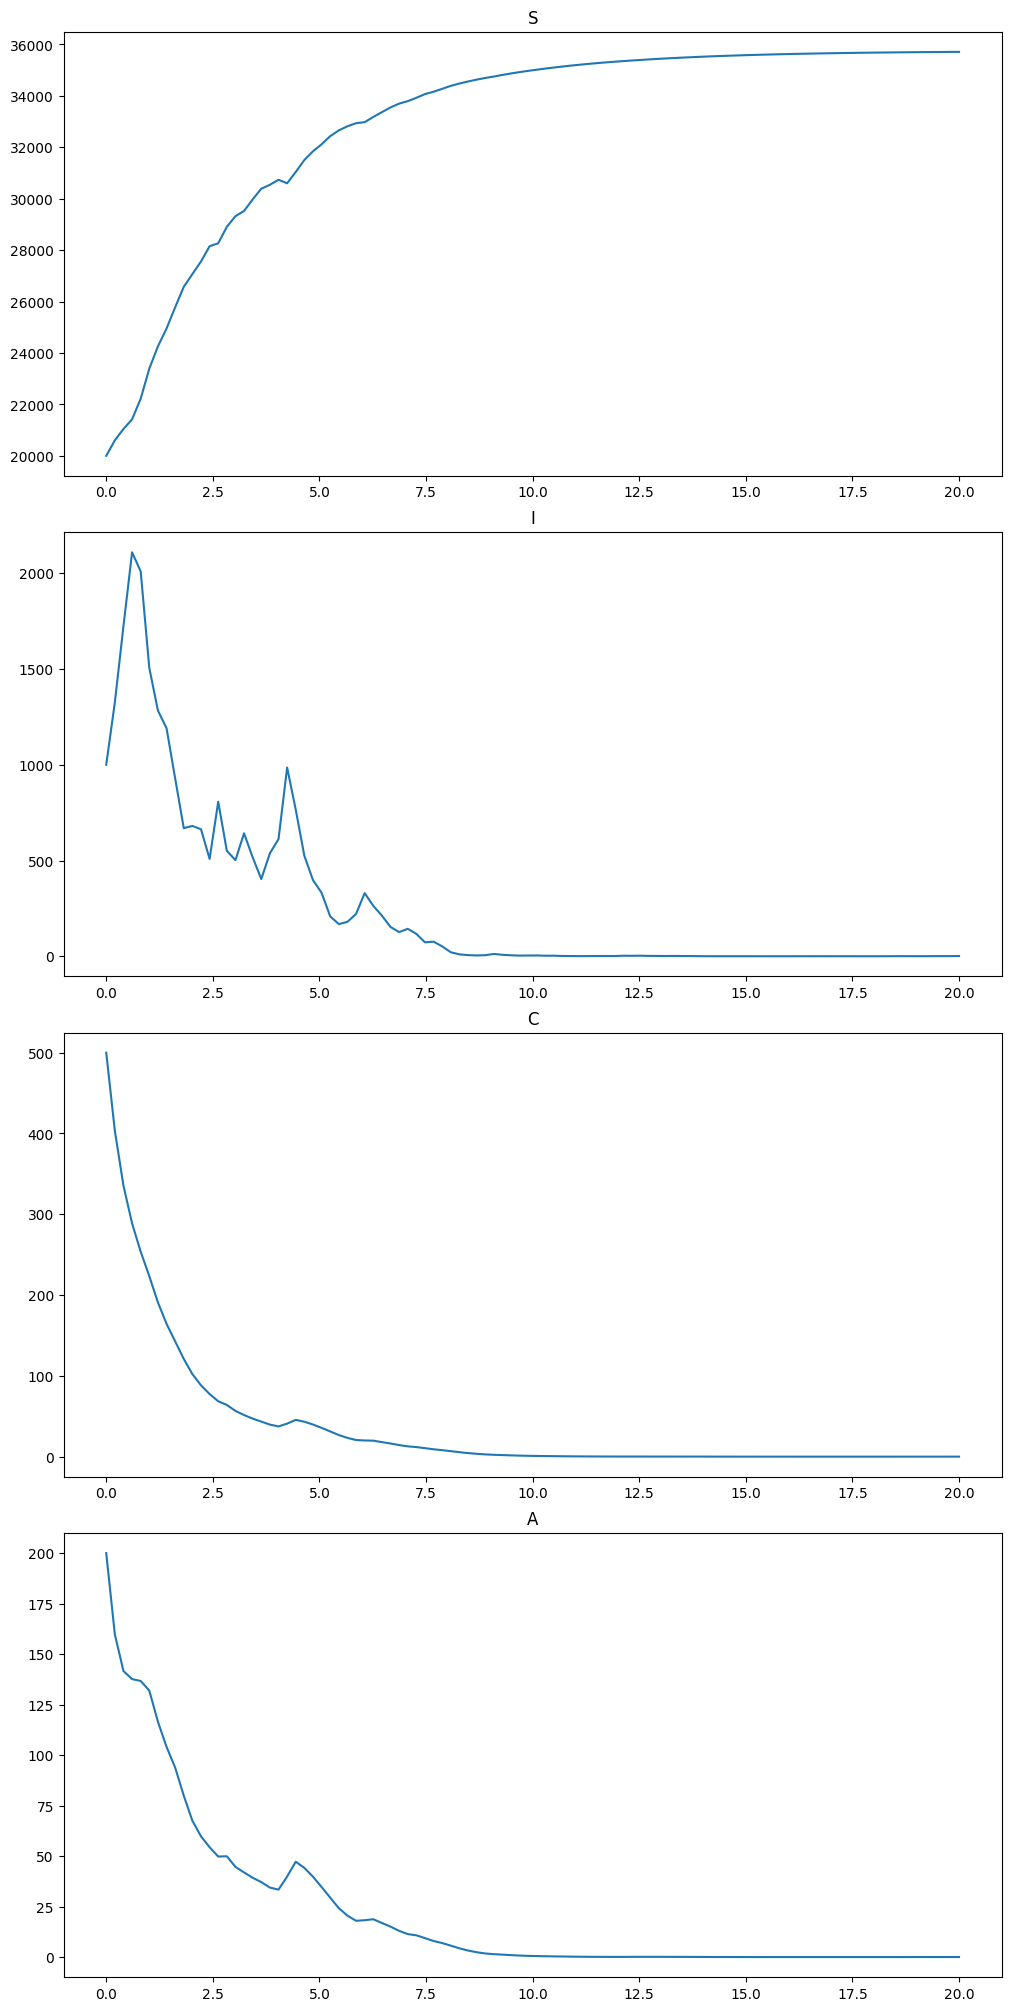

In [9]:
import diffrax
import jax
from jax import numpy as jnp
from matplotlib import pyplot as plt
import numpy as np

sim_times = np.linspace(initial_time, final_time, 100)
dt = (final_time - initial_time) / 1000
dr_term = diffrax.ODETerm(lambda t, y, p: jnp.array(drift_term(t, y, p)))
br_term = diffrax.VirtualBrownianTree(t0=initial_time, t1=final_time, tol=dt / 10, shape=(), key=jax.random.PRNGKey(0))
di_term = diffrax.ControlTerm(lambda t, y, p: jnp.array(diffusion_term(t, y, p)), br_term)
sde_terms = diffrax.MultiTerm(dr_term, di_term)
solver = diffrax.Euler()
solution = diffrax.diffeqsolve(
    sde_terms,
    solver,
    t0=initial_time,
    t1=final_time,
    dt0=dt,
    y0=jnp.asarray([initial_values[n] for n in variable_names]),
    args=jnp.asarray([parameter_values[n] for n in parameter_names]),
    saveat=diffrax.SaveAt(ts=jnp.asarray(sim_times)),
    max_steps=None,
    throw=True
).ys

fig, axs = plt.subplots(len(variable_names), 1, figsize=(10, 5 * len(variable_names)), layout="constrained")
for i, name in enumerate(variable_names):
    axs[i].plot(sim_times, solution[:, i])
    axs[i].set_title(name)

In [10]:
print('Sucessfully defined the SDE model and generated a test simulation plot.')

Sucessfully defined the SDE model and generated a test simulation plot.
